# Intro to Aperiodic L1 Price Metrics

This notebook explores **top-of-book (L1) pricing** with Aperiodic's `l1_price` metric for
**Binance BTC perpetuals** from **September 1, 2025** through **February 28, 2026** at **5-minute** granularity.

## Why L1 data matters

L1 market data focuses on the **best bid and best ask**. That makes it a compact but information-rich view of short-horizon price formation.

With top-of-book data, we can study:
- the best bid / ask and their midpoint,
- quoted size on each side,
- quote update intensity,
- the difference between the simple midpoint and a size-weighted midpoint.

These are core building blocks for thinking about **liquidity, spread, and near-term pressure**.

**Background reading**
- Aperiodic product overview: https://aperiodic.io/
- Binance Academy, order book primer: https://www.binance.com/en/academy/articles/what-is-an-order-book-and-how-does-it-work
- Binance Academy, bid-ask spread: https://www.binance.com/en/academy/articles/bid-ask-spread-and-slippage-explained

In [1]:
from __future__ import annotations

import os
from datetime import date

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from aperiodic import get_metrics, get_ohlcv

sns.set_theme(style="whitegrid", context="talk", palette="deep")
pd.options.display.float_format = "{:,.6f}".format
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 140
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

EXCHANGE = "binance-futures"
SYMBOL = "perpetual-BTC-USDT:USDT"
INTERVAL = "5m"
START_DATE = date(2025, 9, 1)
END_DATE = date(2026, 2, 28)
START_TS = pd.Timestamp(START_DATE)
END_TS = pd.Timestamp(END_DATE) + pd.Timedelta(days=1)
CHART_ZOOM_START = pd.Timestamp(date(2025, 10, 9))
CHART_ZOOM_END = pd.Timestamp(date(2025, 10, 11))

API_KEY = "..."  # Set via APERIODIC_API_KEY env var or .env file
if API_KEY == "...":
    API_KEY = os.getenv("APERIODIC_API_KEY", "...")
if API_KEY == "...":
    API_KEY = "DEMO-KEY"

# Only the shared "DEMO-KEY" runs against the preview endpoint. Provide your own
# key (above or via APERIODIC_API_KEY) to use the standard endpoint.
USE_PREVIEW = API_KEY == "DEMO-KEY"


def clip_window(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["time"] = pd.to_datetime(out["time"])
    out = out.loc[(out["time"] >= START_TS) & (out["time"] < END_TS)]
    return out.sort_values("time").reset_index(drop=True)

def format_time_axis(ax):
    locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
    formatter = mdates.ConciseDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)



## Fetch BTC close and L1 price metrics

In [2]:
price = clip_window(
    get_ohlcv(
        api_key=API_KEY,
        preview=USE_PREVIEW,
        timestamp="true",
        interval=INTERVAL,
        exchange=EXCHANGE,
        symbol=SYMBOL,
        start_date=START_DATE,
        end_date=END_DATE,
        output="pandas",
        show_progress=False,
    )
)[["time", "close"]]

l1 = clip_window(
    get_metrics(
        api_key=API_KEY,
        preview=USE_PREVIEW,
        metric="l1_price",
        timestamp="true",
        interval=INTERVAL,
        exchange=EXCHANGE,
        symbol=SYMBOL,
        start_date=START_DATE,
        end_date=END_DATE,
        output="pandas",
        show_progress=False,
    )
)

In [3]:
l1 = l1.merge(price, on="time", how="left")
l1["spread"] = l1["ask_price"] - l1["bid_price"]
l1["spread_bps"] = (l1["spread"] / l1["midprice"]) * 10_000
l1["weighted_mid_premium_bps"] = ((l1["weighted_midprice"] - l1["midprice"]) / l1["midprice"]) * 10_000
l1["depth_imbalance"] = (l1["bid_amount"] - l1["ask_amount"]) / (l1["bid_amount"] + l1["ask_amount"])
l1["rolling_spread_bps_1d"] = l1["spread_bps"].rolling(288).mean()
l1["rolling_quote_updates_1d"] = l1["quote_update_frequency"].rolling(288).mean()
l1["mid_return_5m_bps"] = l1["midprice"].pct_change() * 10_000
l1["realized_vol_1d_bps"] = l1["mid_return_5m_bps"].rolling(288).std() * np.sqrt(288)
l1["next_15m_return_bps"] = l1["midprice"].pct_change(3).shift(-3) * 10_000

summary = pd.Series(
    {
        "Rows": len(l1),
        "Start": l1["time"].min(),
        "End": l1["time"].max(),
        "Average spread (bps)": l1["spread_bps"].mean(),
        "Average quote updates / bar": l1["quote_update_frequency"].mean(),
        "Average bid amount": l1["bid_amount"].mean(),
        "Average ask amount": l1["ask_amount"].mean(),
    }
)
summary

l1_zoom = l1.loc[(l1["time"] >= CHART_ZOOM_START) & (l1["time"] < CHART_ZOOM_END)].copy()

## Chart 1 — Midprice with the bid-ask band

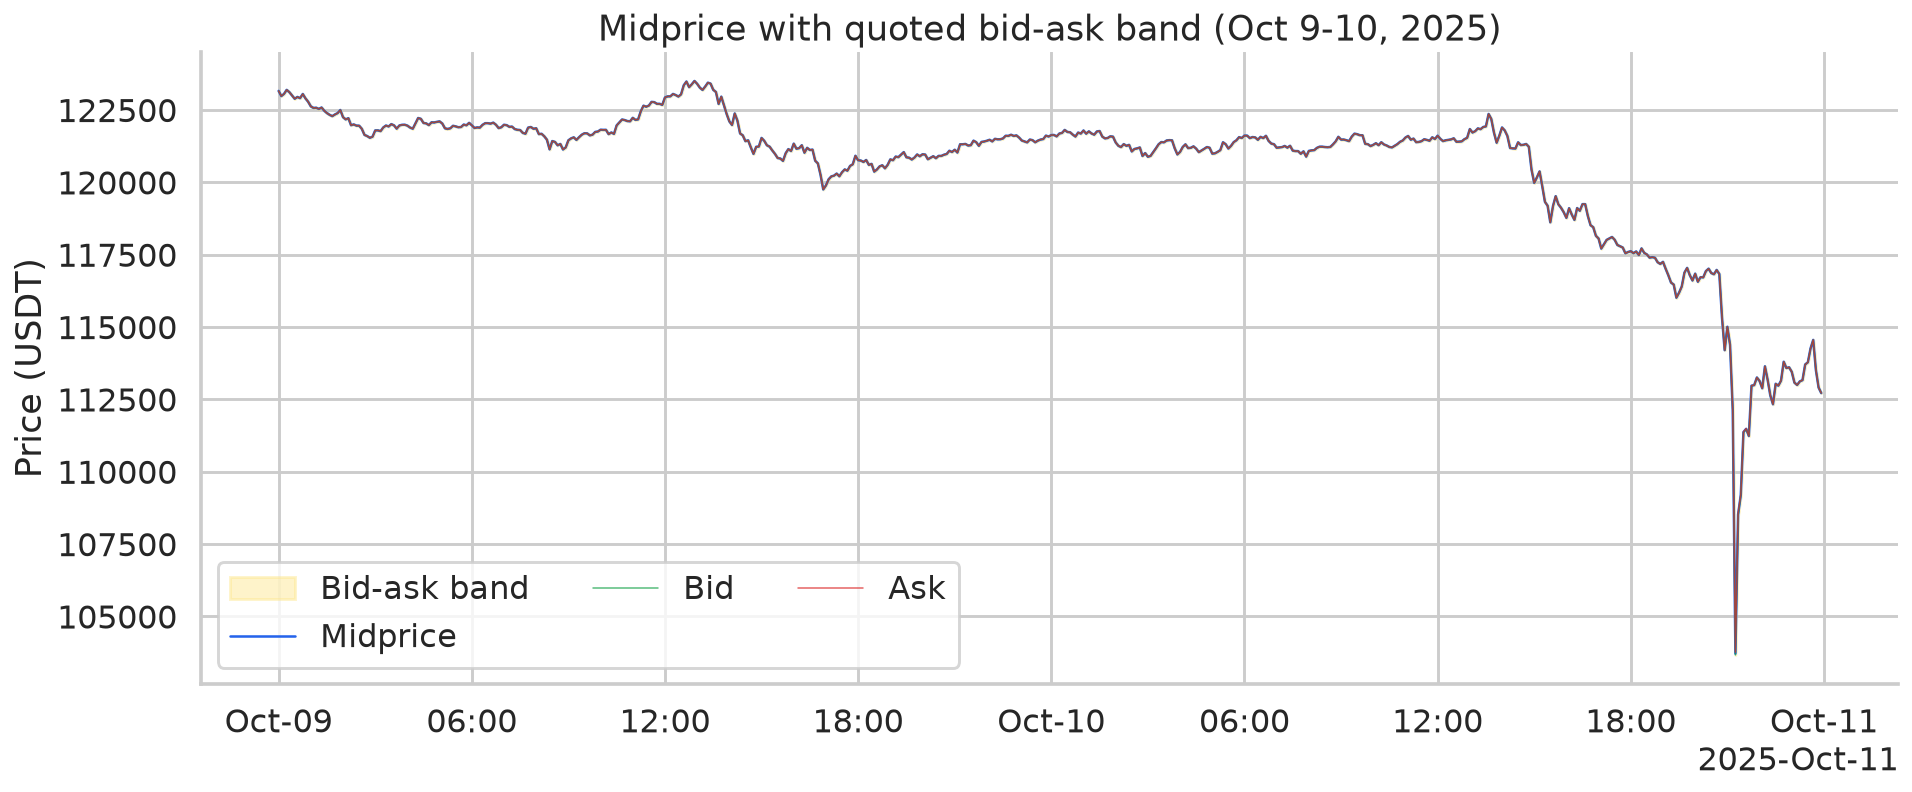

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.fill_between(
    l1_zoom["time"],
    l1_zoom["bid_price"],
    l1_zoom["ask_price"],
    color="#fde68a",
    alpha=0.45,
    label="Bid-ask band",
)
ax.plot(l1_zoom["time"], l1_zoom["midprice"], color="#2563eb", linewidth=1.3, label="Midprice")
ax.plot(l1_zoom["time"], l1_zoom["bid_price"], color="#16a34a", linewidth=0.8, alpha=0.7, label="Bid")
ax.plot(l1_zoom["time"], l1_zoom["ask_price"], color="#dc2626", linewidth=0.8, alpha=0.7, label="Ask")
ax.set_title("Midprice with quoted bid-ask band (Oct 9-10, 2025)")
ax.set_ylabel("Price (USDT)")
ax.legend(frameon=True, ncol=3)
format_time_axis(ax)
plt.tight_layout()

## Chart 2 — Weighted midpoint vs simple midpoint

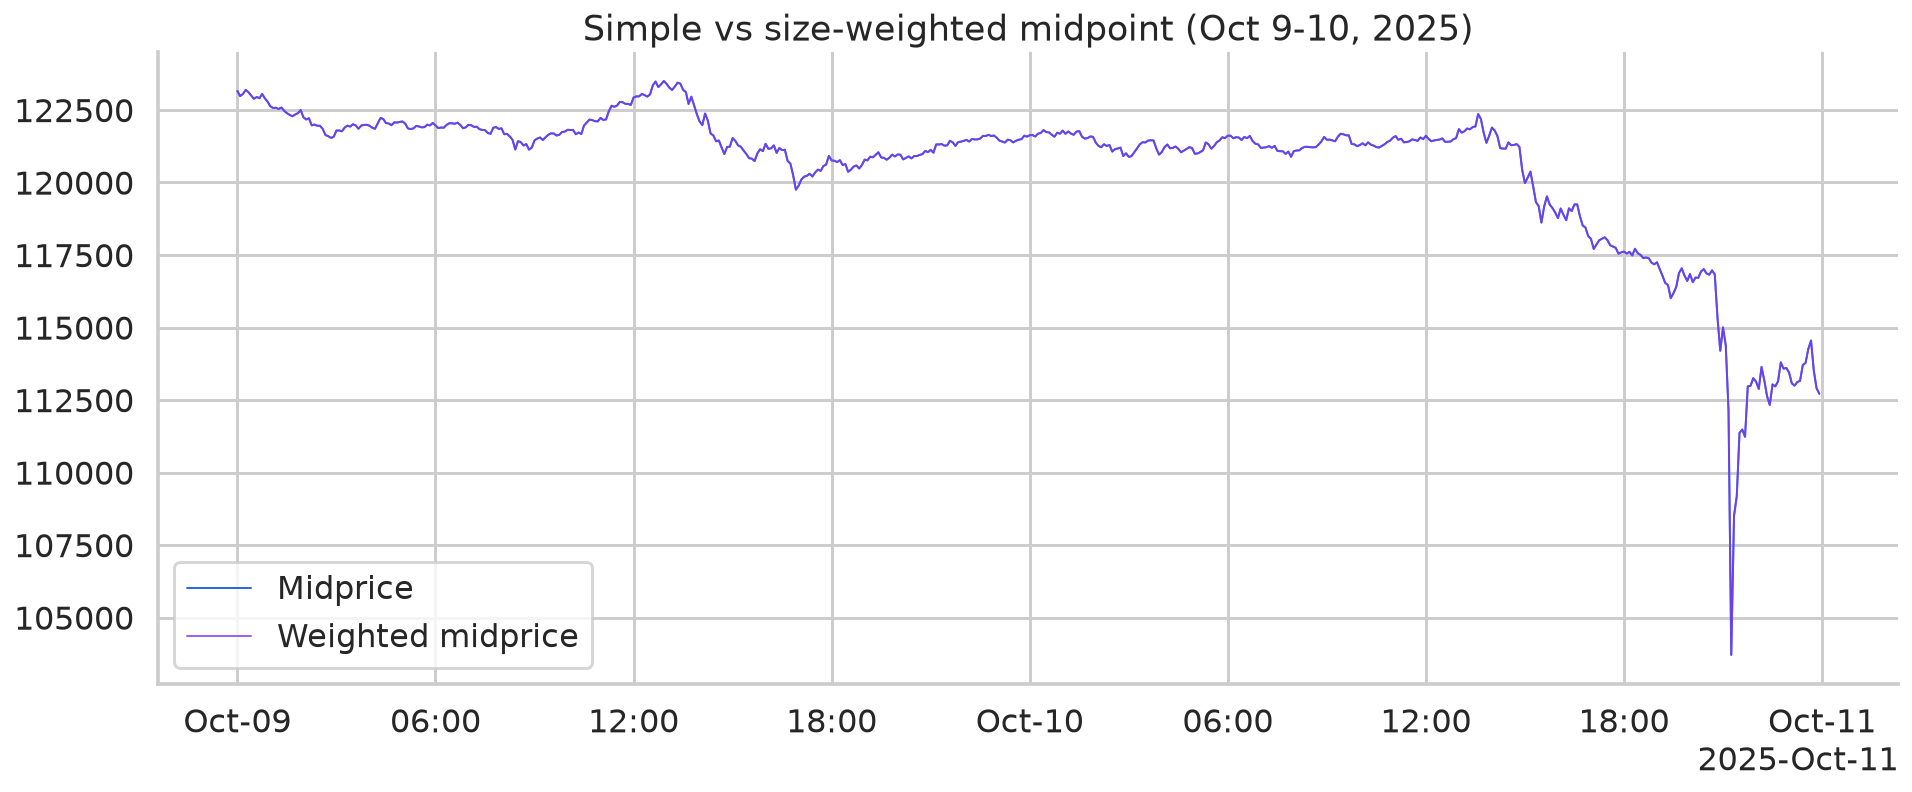

In [5]:
fig, ax = plt.subplots()
ax.plot(l1_zoom["time"], l1_zoom["midprice"], label="Midprice", color="#2563eb", linewidth=1)
ax.plot(
    l1_zoom["time"],
    l1_zoom["weighted_midprice"],
    label="Weighted midprice",
    color="#7c3aed",
    linewidth=1,
    alpha=0.8,
)
ax.set_title("Simple vs size-weighted midpoint (Oct 9-10, 2025)")
ax.legend(frameon=True)
format_time_axis(ax)
plt.tight_layout()

## Chart 3 — Bid-ask spread in basis points

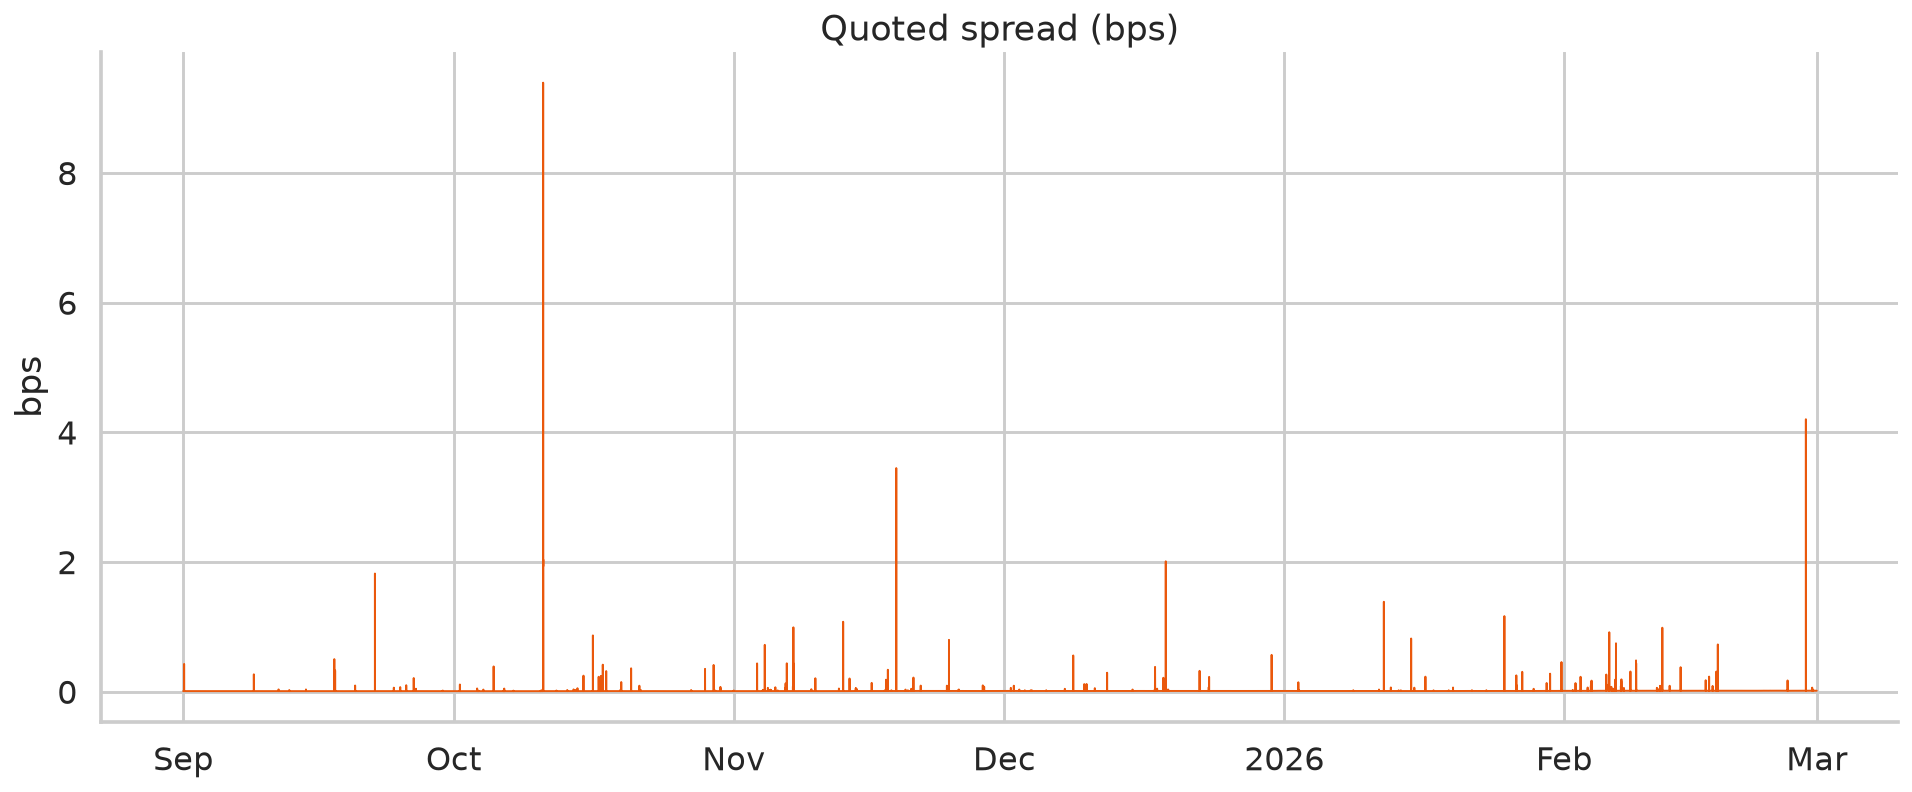

In [6]:
fig, ax = plt.subplots()
ax.plot(l1["time"], l1["spread_bps"], color="#ea580c", linewidth=1)
ax.set_title("Quoted spread (bps)")
ax.set_ylabel("bps")
format_time_axis(ax)
plt.tight_layout()

## Chart 4 — Quote update frequency

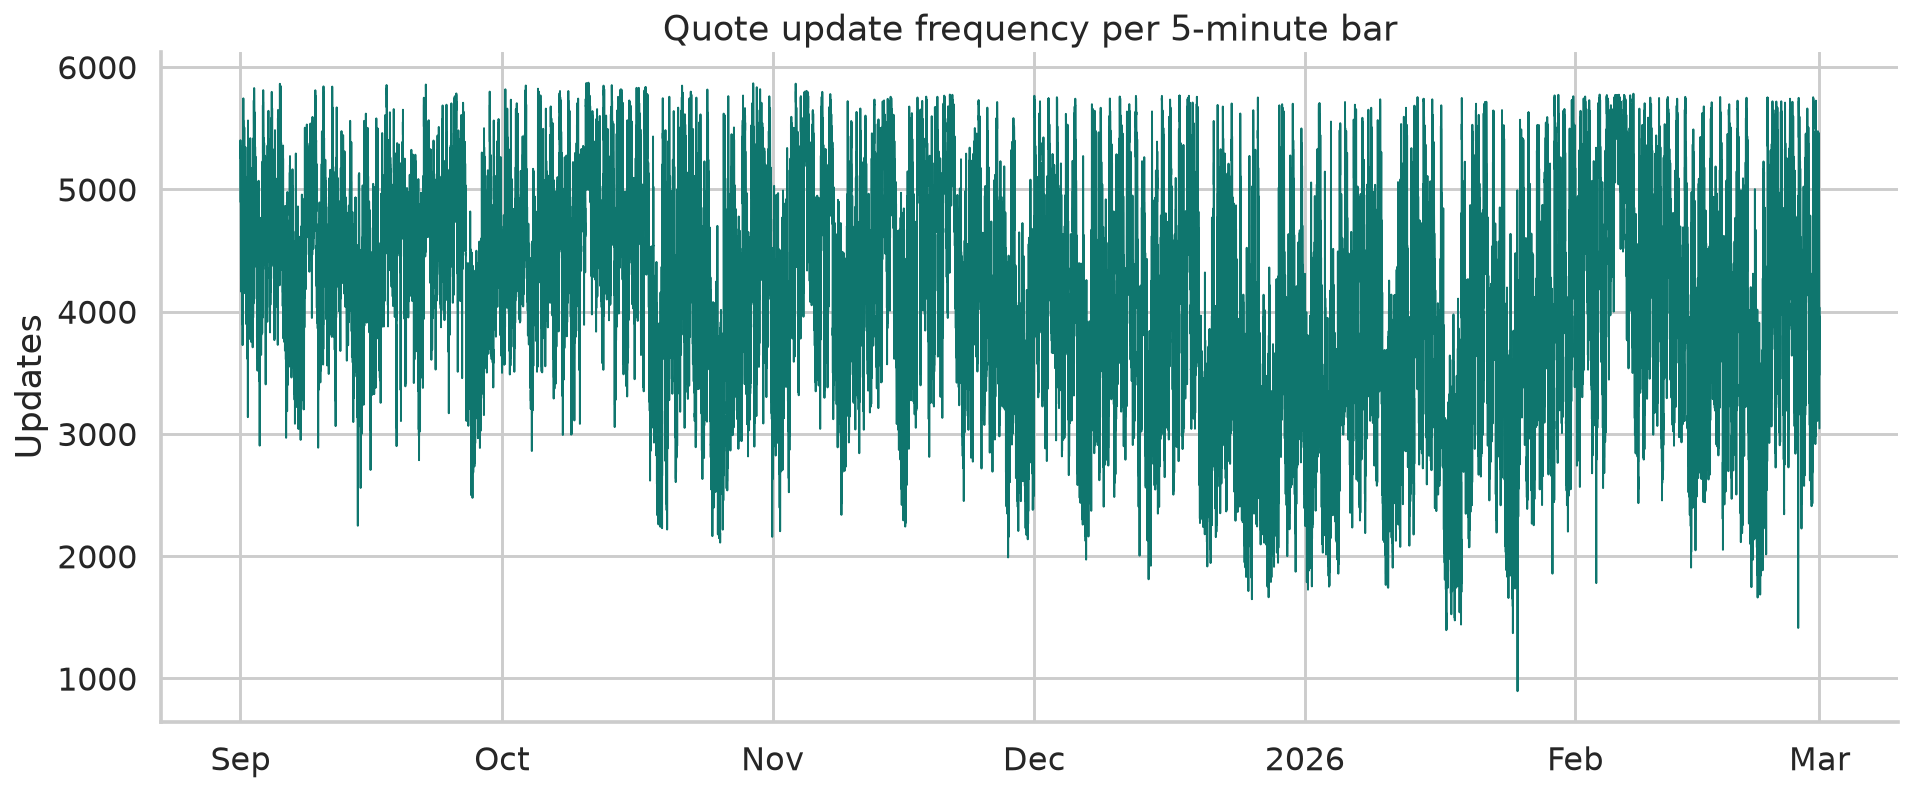

In [7]:
fig, ax = plt.subplots()
ax.plot(l1["time"], l1["quote_update_frequency"], color="#0f766e", linewidth=1)
ax.set_title("Quote update frequency per 5-minute bar")
ax.set_ylabel("Updates")
format_time_axis(ax)
plt.tight_layout()

## Chart 5 — Rolling realized volatility from midprice

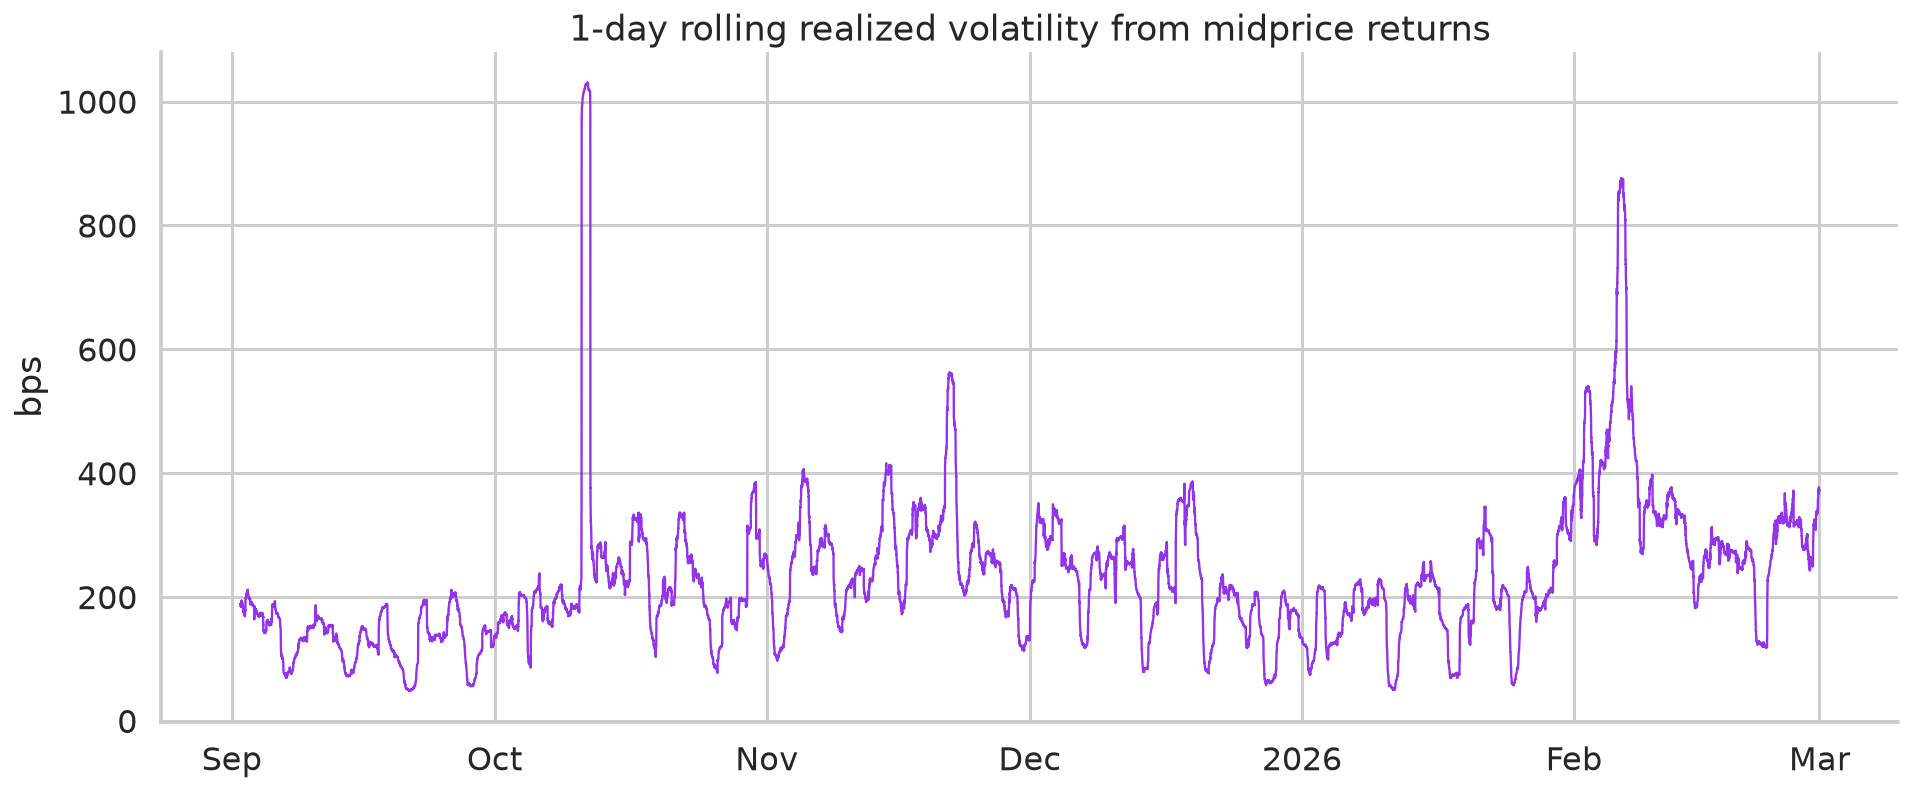

In [8]:
fig, ax = plt.subplots()
ax.plot(l1["time"], l1["realized_vol_1d_bps"], color="#9333ea", linewidth=1.2)
ax.set_title("1-day rolling realized volatility from midprice returns")
ax.set_ylabel("bps")
format_time_axis(ax)
plt.tight_layout()

## Chart 6 — Weighted-mid premium and next 15-minute returns

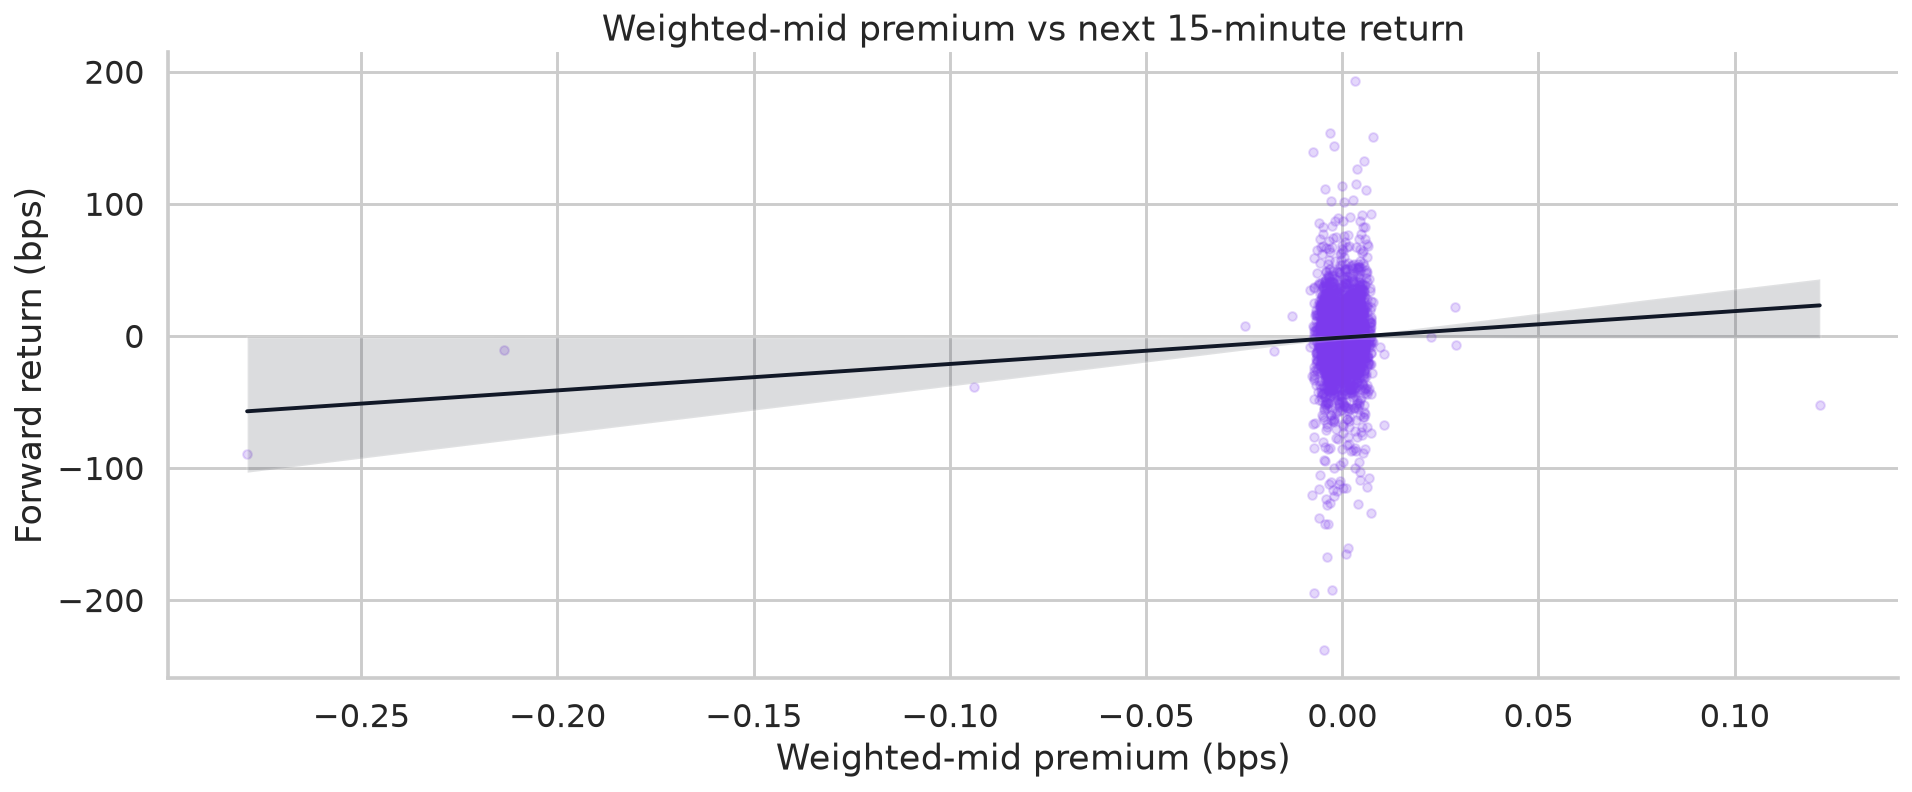

In [9]:
scatter = l1[["weighted_mid_premium_bps", "next_15m_return_bps"]].dropna()
fig, ax = plt.subplots()
sns.regplot(
    data=scatter.sample(min(len(scatter), 4000), random_state=7),
    x="weighted_mid_premium_bps",
    y="next_15m_return_bps",
    scatter_kws={"alpha": 0.2, "s": 20, "color": "#7c3aed"},
    line_kws={"color": "#111827", "linewidth": 2},
    ax=ax,
)
ax.set_title("Weighted-mid premium vs next 15-minute return")
ax.set_xlabel("Weighted-mid premium (bps)")
ax.set_ylabel("Forward return (bps)")
plt.tight_layout()

## Chart 7 — Top-of-book size imbalance

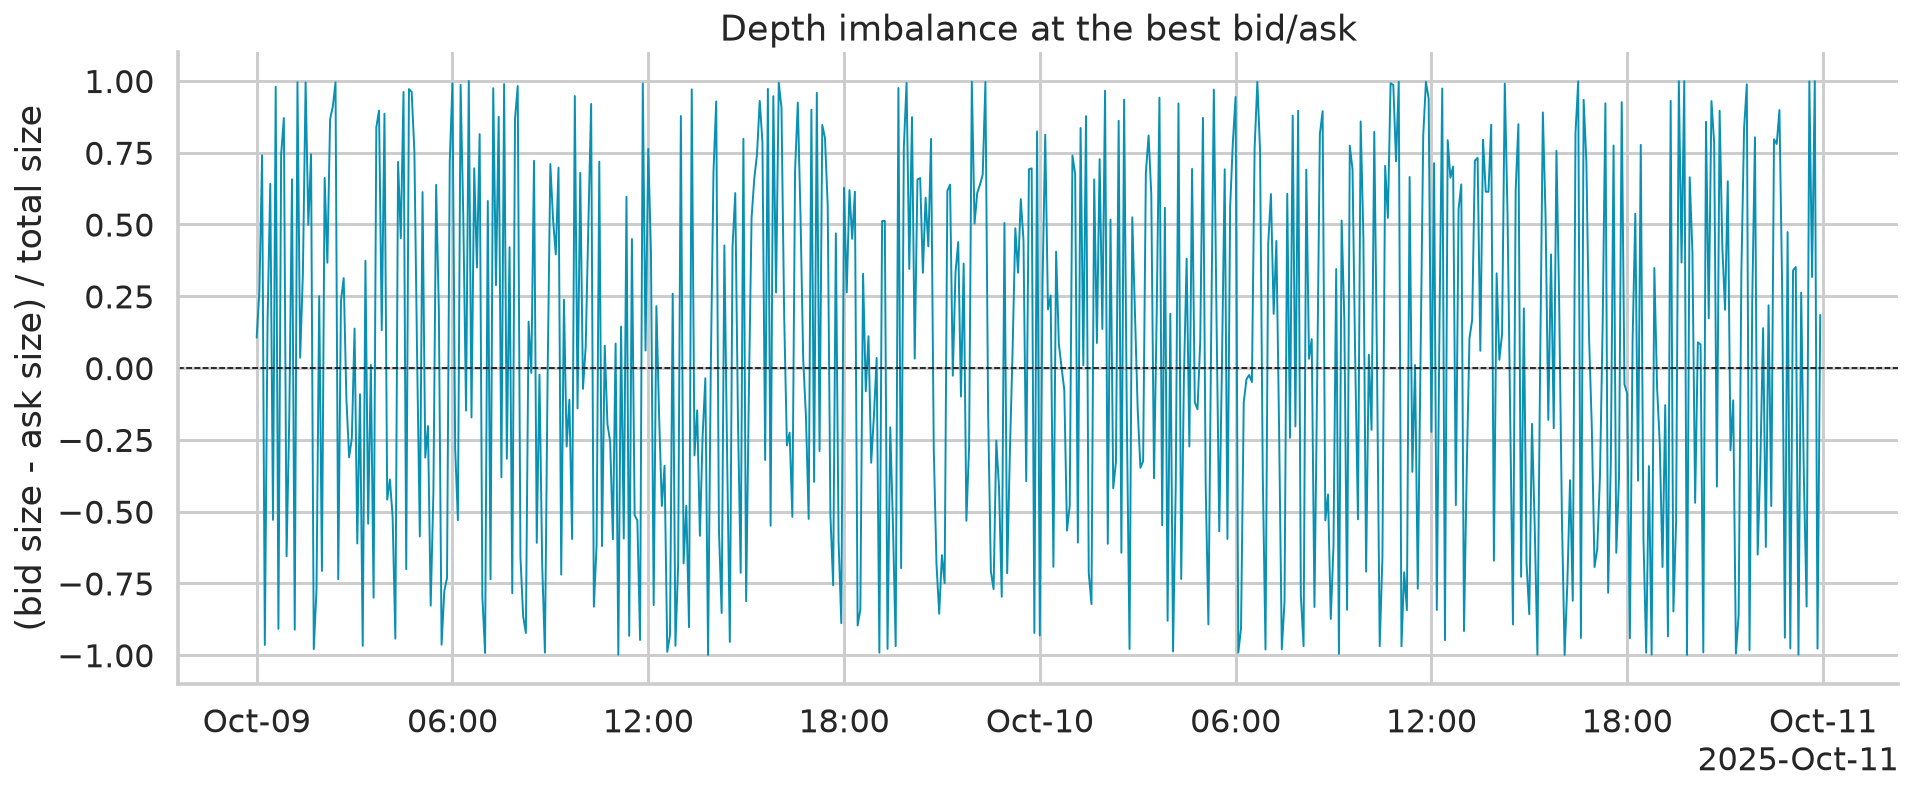

In [10]:
fig, ax = plt.subplots()
ax.plot(l1_zoom["time"], l1_zoom["depth_imbalance"], color="#0891b2", linewidth=1)
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Depth imbalance at the best bid/ask")
ax.set_ylabel("(bid size - ask size) / total size")
format_time_axis(ax)
plt.tight_layout()

## Takeaways

- L1 data gives a compact view of **price, spread, and displayed liquidity**.
- Quote update frequency is a useful proxy for how mechanically active the book is.
- Weighted-mid deviations can add color on near-term pressure when one side of the book is relatively thicker.
- Even in a very liquid instrument like BTC perpetuals, spread and top-of-book size still vary meaningfully across the day.

## Further reading
- Aperiodic: https://aperiodic.io/
- Order books: https://www.binance.com/en/academy/articles/what-is-an-order-book-and-how-does-it-work
- Bid-ask spread: https://www.binance.com/en/academy/articles/bid-ask-spread-and-slippage-explained
